# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [28]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [29]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()

from visualization import *

## B. Introducing a CO2 contraint
Investigate how sensitive the optimum capacity mix is to the global CO2 constraint. E.g., plot the generation mix as a function of the CO2 constraint that you impose. Search for the CO2 emissions in your country (today or in 1990) and refer to the emissions allowance to that historical data.

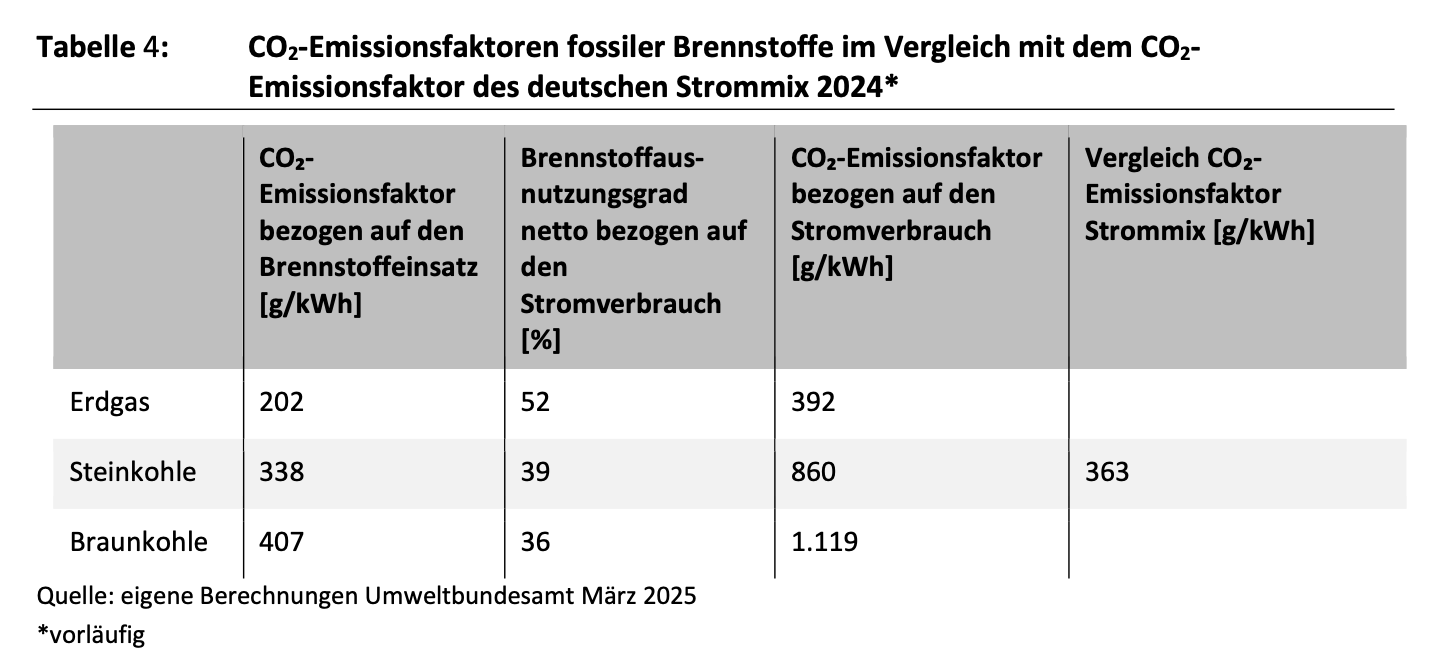

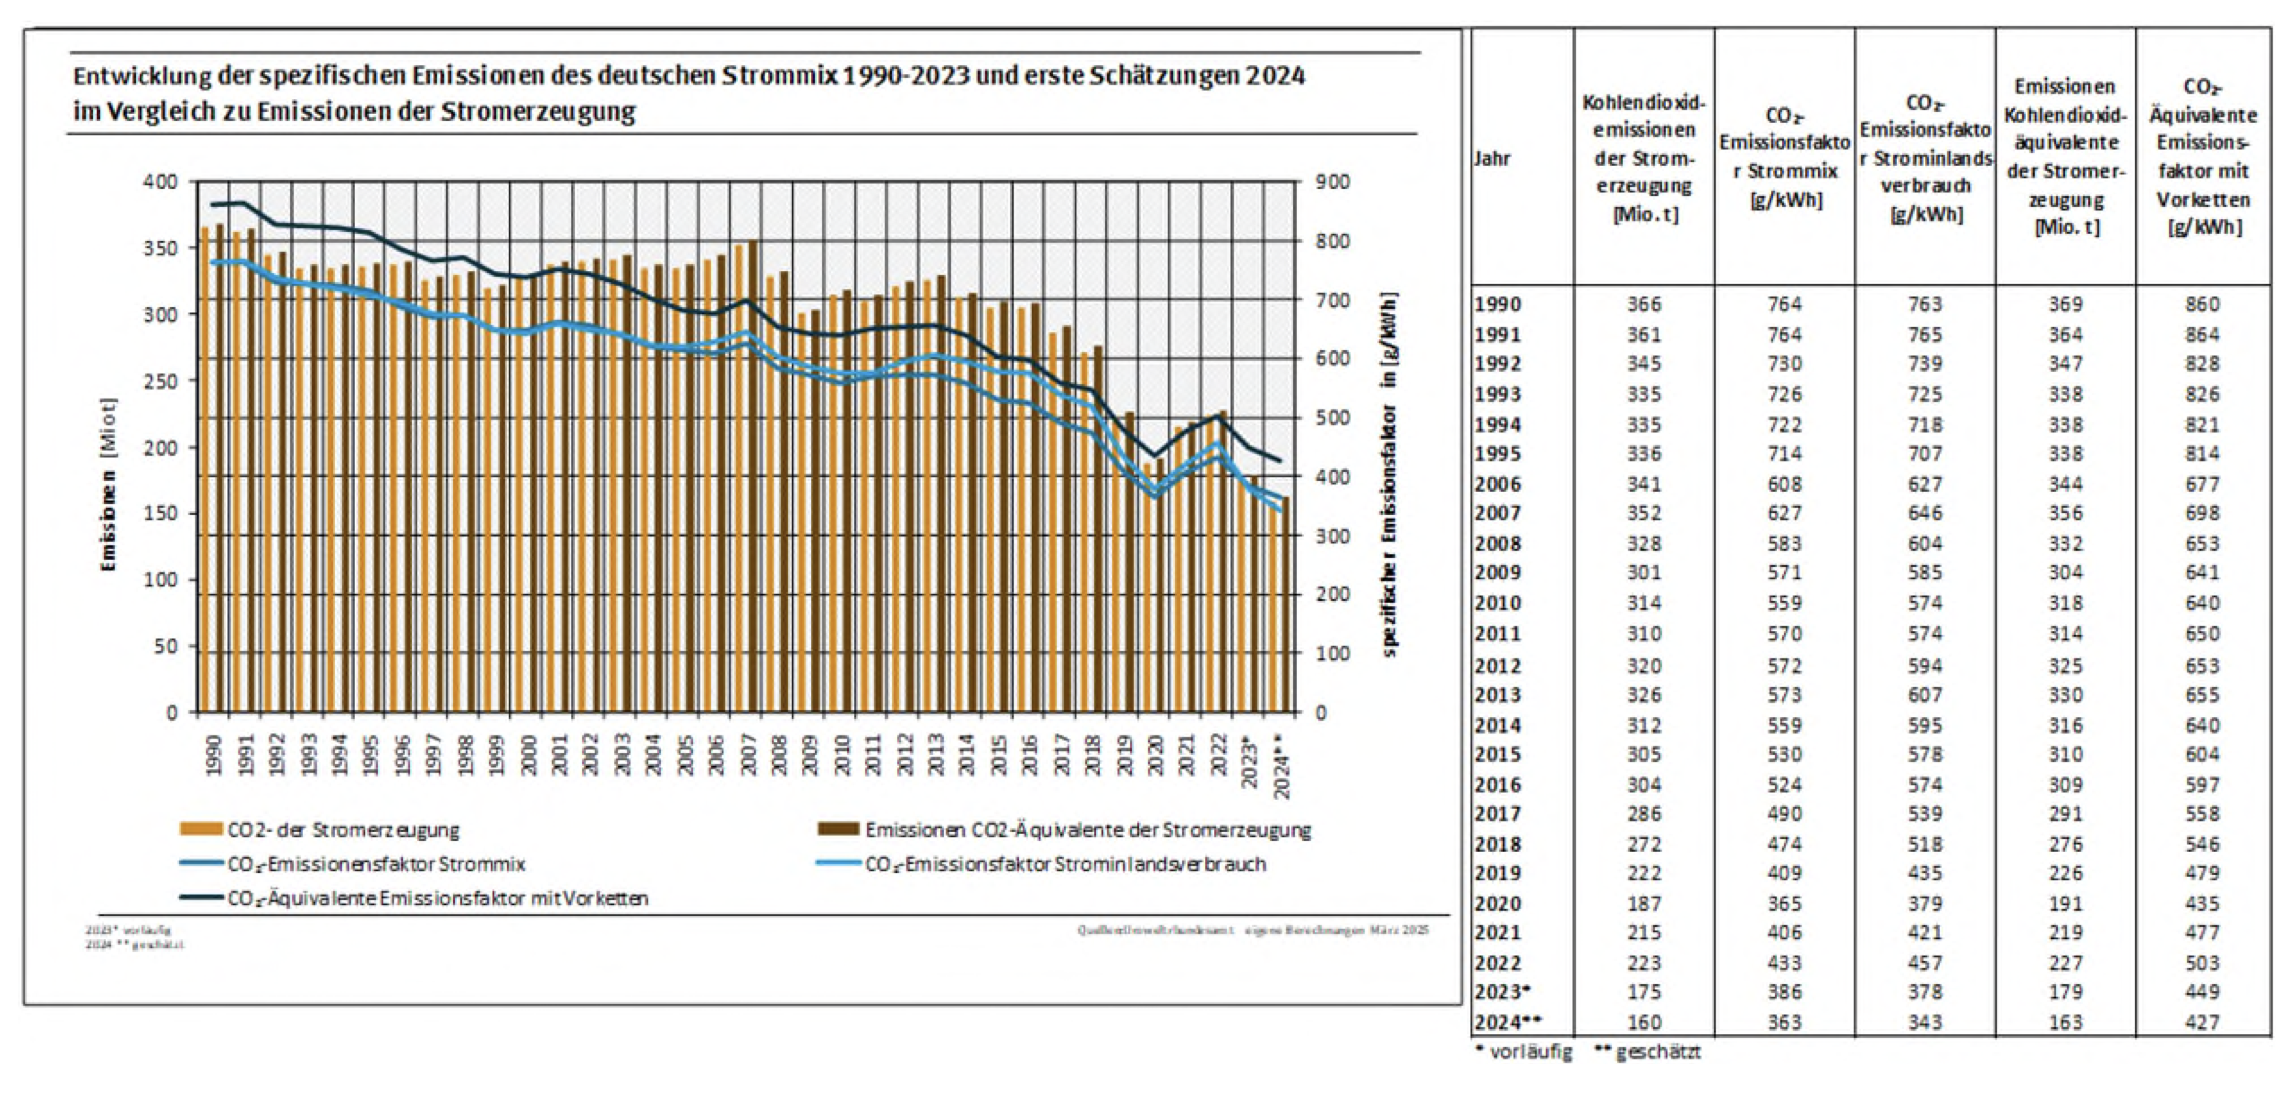

Source: https://www.umweltbundesamt.de/sites/default/files/medien/11850/publikationen/13_2025_cc.pdf, https://www.umweltbundesamt.de/daten/klima/treibhausgasminderungsziele-deutschlands#projektionsdaten-2024

In [30]:
network = base.build_network(solve=False)

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


### Study I: Add CO2 constraint of german emissions in 2015

In [31]:
co2_emissions_2015 = 310e6

In [32]:
network.add("GlobalConstraint", "CO2Limit",
          carrier_attribute="co2_emissions",
          sense="<=",
          constant=co2_emissions_2015)

network.optimize(solver_name="gurobi", solver_options={"InfUnbdInfo": 1})

Index(['DEU_elec'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - InfUnbdInfo: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 22.26it/s]
INFO:linopy.io: Writing time: 0.7s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


INFO:gurobipy:Set parameter LicenseID to value 2625590


...

Solved in 8 iterations and 12.28 seconds (10.25 work units)


INFO:gurobipy:Solved in 8 iterations and 12.28 seconds (10.25 work units)


Optimal objective  4.353732934e+10


INFO:gurobipy:Optimal objective  4.353732934e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70088 primals, 148934 duals
Objective: 4.35e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [33]:
# check some numbers

print(f"System cost: {round(network.objective / 1e9, 2)} billion euros")
print("")
print("Optimal Generator Capactities in GW:")
print(network.generators.p_nom_opt.div(1e3))  # MW -> GW
print("")
print("Optimal Energy Generation in GWh/a")
print(network.generators_t.p.sum().div(1e6))

# Total emissions in the system (sum over all generators and time)
actual_emissions = (
    network.generators_t.p
    .multiply(network.generators.carrier.map(network.carriers["co2_emissions"]))
    .sum()
    .sum()
)

# The imposed CO₂ limit (from GlobalConstraint)
co2_limit = network.global_constraints.at["CO2Limit", "constant"]

print(f"Actual emissions: {actual_emissions:.2e} t")
print(f"CO₂ constraint  : {co2_limit:.2e} t")

dual = network.global_constraints.at["CO2Limit", "mu"]
print(f"Shadow price of CO₂: {dual:.2f} €/tCO2")

System cost: 43.54 billion euros

Optimal Generator Capactities in GW:
Generator
coal            7.423644
lignite        21.000000
biomass CHP    10.000000
OCGT           31.000000
ror             6.000000
onwind         98.333441
offwind        20.114600
solar          44.879987
Name: p_nom_opt, dtype: float64

Optimal Energy Generation in GWh/a
Generator
coal            21.540602
lignite         76.251415
biomass CHP     62.072552
OCGT           111.164573
ror             16.444508
onwind         108.613768
offwind         62.945787
solar           46.231357
dtype: float64
Actual emissions: 1.33e+08 t
CO₂ constraint  : 3.10e+08 t
Shadow price of CO₂: -189.31 €/tCO2


### Study II: Adding relative constraints for emission reductions compared to 1990

In [ ]:
# Introduce relative CO2 constraints 
co2_emissions_1990 = 369e6
emission_limits = [100, 1.0, 0.8, 0.6, 0.4, 0.2, 0.1, 0.0]  
emission_scenarios = [x*co2_emissions_1990 for x in emission_limits]

In [ ]:
networks = []

# run different optimization problems for the emission scenarios and append results to the list
for limit in emission_scenarios:
    n = base.build_network(solve=False)
    n.add("GlobalConstraint", "CO2Limit",
          type="primary_energy",
          carrier_attribute="co2_emissions",
          sense="<=",
          constant=limit)
    # Solve
    n.optimize(solver_name="gurobi")
    networks.append(n)

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour
Index(['DEU_elec'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 22.41it/s]
INFO:linopy.io: Writing time: 0.68s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


INFO:gurobipy:Set parameter LicenseID to value 2625590


...

INFO:gurobipy:


Solved in 39374 iterations and 10.10 seconds (6.81 work units)


INFO:gurobipy:Solved in 39374 iterations and 10.10 seconds (6.81 work units)


Optimal objective  4.526906375e+11


INFO:gurobipy:Optimal objective  4.526906375e+11
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70088 primals, 148934 duals
Objective: 4.53e+11
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


### Result Analysis

In [36]:
def extract_results(networks, emission_scenarios):
    """
    Extract generation mix, system costs, and actual emissions from optimized PyPSA networks.

    Parameters:
        networks (list of pypsa.Network): One network per CO2 scenario
        emission_scenarios (list of float): CO2 constraint values (same order as networks)

    Returns:
        df_mix (DataFrame): Generation per carrier [MWh], indexed by CO2 limit
        df_costs (DataFrame): System cost and actual emissions per scenario
    """
    import pandas as pd

    generation_by_carrier = {}
    system_costs = []
    actual_emissions = []

    for net, co2_limit in zip(networks, emission_scenarios):
        # Total generation per carrier (MWh)
        generation = net.generators_t.p.sum().groupby(net.generators.carrier).sum()
        generation_by_carrier[co2_limit] = generation

        # Total system cost (objective)
        try:
            system_costs.append(net.objective)
        except:
            ("fail")

        # Actual emissions from generators
        co2_series = net.generators.carrier.map(net.carriers["co2_emissions"])
        emissions = (net.generators_t.p * co2_series).sum().sum()
        actual_emissions.append(emissions)

    # Convert to DataFrames
    df_mix = pd.DataFrame(generation_by_carrier).T  # Index = CO₂ constraint
    df_mix.index.name = "CO2 Limit [Mio t/year]"

    df_costs = pd.DataFrame({
        "CO2 Limit [Mt]": [int(e / 1e6) for e in emission_scenarios],
        "System Cost [billion €]": [c / 1e9 for c in system_costs],
        "Actual CO2 Emissions [Mt]": [e / 1e6 for e in actual_emissions]
    }, index=emission_scenarios)

    return df_mix, df_costs


In [37]:
df_mix, df_costs = extract_results(networks, emission_scenarios)
df_mix

carrier,OCGT,biomass CHP,coal,lignite,offwind,onwind,ror,solar
CO2 Limit [Mio t/year],,,,,,,,
3.690000e+10,1.157088e+08,8.760000e+07,1.112369e+08,1.822584e+08,8.460432e+06,0.000000e+00,0.000000e+00,0.000000e+00
3.690000e+08,1.637874e+08,8.125360e+07,2.827321e+07,8.285508e+07,4.589691e+07,5.216675e+07,1.644451e+07,3.458715e+07
2.952000e+08,1.000573e+08,5.717205e+07,1.876654e+07,7.558896e+07,5.418900e+07,1.430504e+08,1.644451e+07,3.999574e+07
2.214000e+08,6.671661e+07,3.797271e+07,8.468392e+05,7.389899e+07,9.680685e+07,2.025744e+08,1.644451e+07,1.000364e+07
1.476000e+08,5.829247e+07,3.225831e+07,0.000000e+00,4.786894e+07,9.730684e+07,2.528077e+08,1.644451e+07,2.857742e+05
7.380000e+07,5.534618e+07,3.008820e+07,0.000000e+00,1.999351e+07,9.755346e+07,2.697534e+08,1.644451e+07,1.608529e+07
3.690000e+07,5.485616e+07,2.960270e+07,0.000000e+00,5.907915e+06,9.761722e+07,2.760309e+08,1.644451e+07,2.480517e+07
0.000000e+00,0.000000e+00,2.893346e+07,0.000000e+00,0.000000e+00,8.696400e+07,2.365459e+08,1.644451e+07,1.363767e+08


In [38]:
df_costs

,CO2 Limit [Mt],System Cost [billion €],Actual CO2 Emissions [Mt]
3.690000e+10,36900,31.888247,326.574198
3.690000e+08,369,38.926978,167.097730
2.952000e+08,295,46.757234,125.228752
2.214000e+08,221,83.219395,90.653659
1.476000e+08,147,134.002942,64.017935
7.380000e+07,73,188.607606,38.890121
3.690000e+07,36,216.348785,26.584423
0.000000e+00,0,452.690638,0.000000


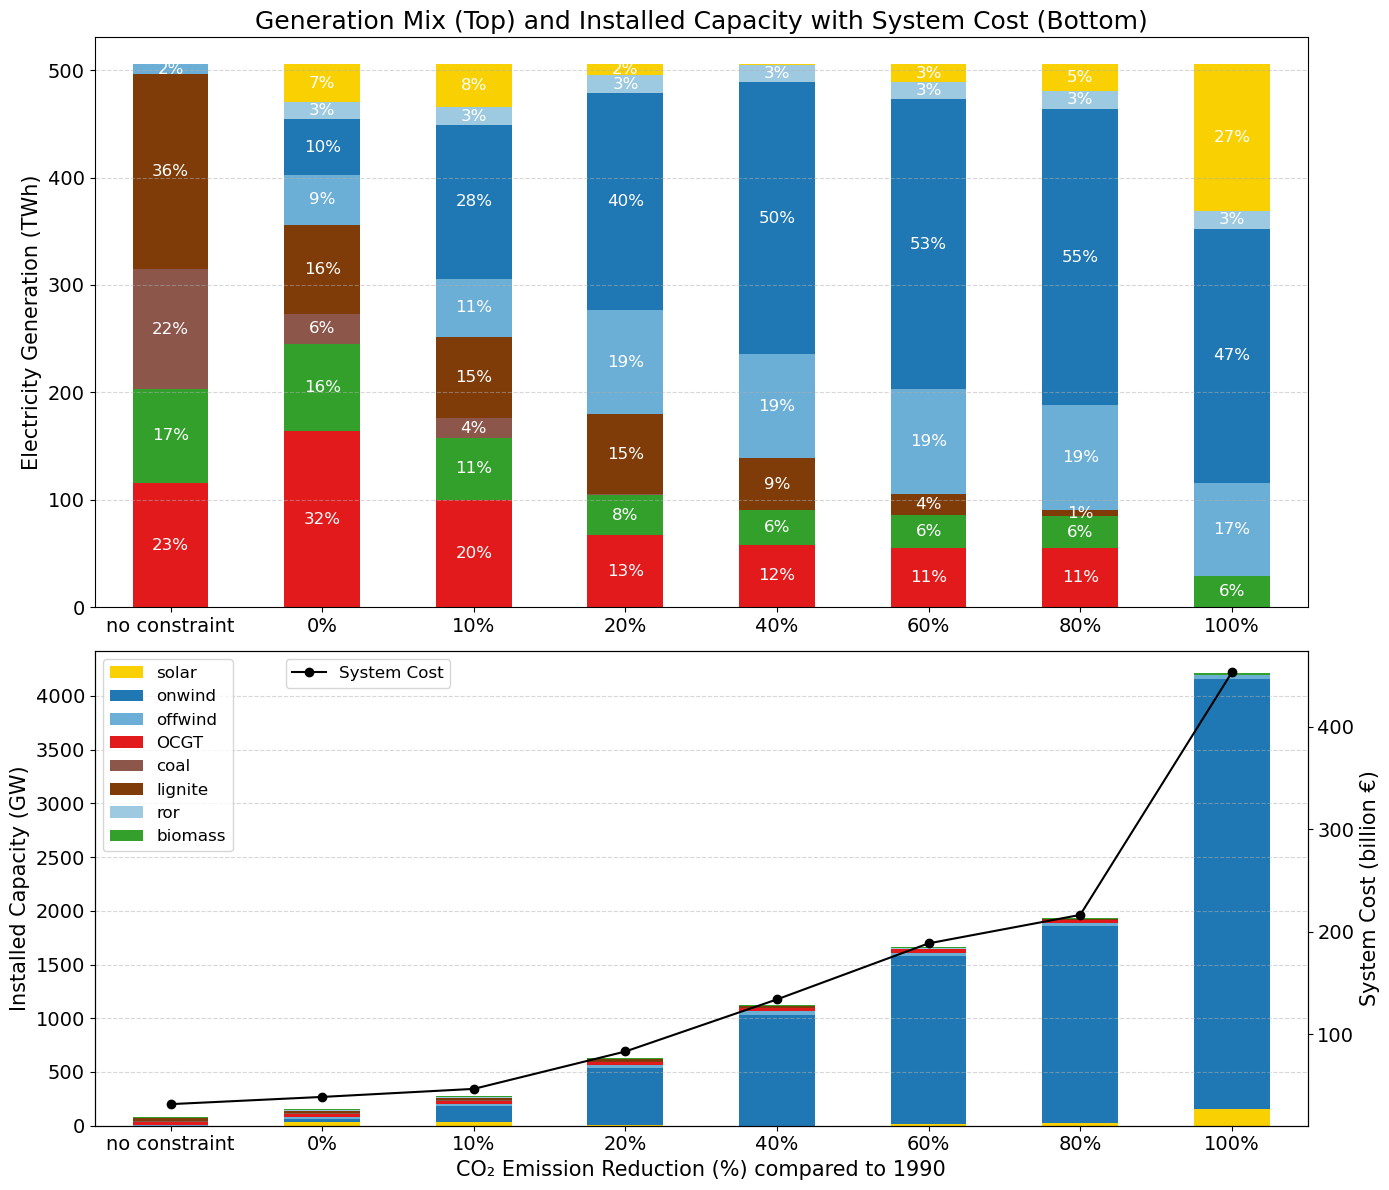

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Define reduction labels (100% allowance -> 0% reduction, etc.)
reduction_labels = ["no constraint", "0%", "10%", "20%", "40%", "60%", "80%", "100%"]

df_capacity = {}

for label, net in zip(reduction_labels, networks):
    cap = net.generators.groupby("carrier")["p_nom_opt"].sum()
    df_capacity[label] = cap

df_capacity = pd.DataFrame(df_capacity).T.fillna(0)  # shape: (scenarios, carriers)
df_capacity.index.name = "CO₂ Scenario"

# Clean and order columns as in df_mix
df_capacity.columns = df_capacity.columns.str.strip()
df_capacity = df_capacity[[col for col in color_map.keys() if col in df_capacity.columns]]
colors_capacity = [color_map.get(tech, "#999999") for tech in df_capacity.columns]

# Ensure your index labels are aligned across both dataframes
df_capacity.index = reduction_labels
df_costs.index = reduction_labels

# Build consistent color list for stacked bars
df_capacity = df_capacity[[col for col in color_map.keys() if col in df_capacity.columns]]
colors_capacity = [color_map.get(tech, "#999999") for tech in df_capacity.columns]


# Get colors
colors_mix = [color_map.get(tech, "#999999") for tech in df_mix.columns]
colors_capacity = [color_map.get(tech, "#999999") for tech in df_capacity.columns]

# --- Create subplot layout ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1.2, 1]})

# --- Upper plot: Generation mix ---
bars = (df_mix / 1e6)
bars.plot(kind="bar", stacked=True, color=colors_mix, ax=ax1)
ax1.set_title("Generation Mix (Top) and Installed Capacity with System Cost (Bottom)", fontsize=18)
ax1.set_ylabel("Electricity Generation (TWh)", fontsize=15)
ax1.set_xlabel("", fontsize=15)
ax1.set_xticklabels(reduction_labels, rotation=0, fontsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend().remove()

# Add percentage annotations to generation mix
for i, label in enumerate(df_mix.index):
    total = bars.loc[label].sum()
    bottom = 0
    for tech, color in zip(bars.columns, colors_mix):
        val = bars.loc[label, tech]
        if val > 0:
            percent = val / total * 100
            if percent > 1:
                ax1.text(i, bottom + val / 2, f"{percent:.0f}%", ha="center", va="center",
                         fontsize=12, color="white")
            bottom += val

# --- Lower plot: Installed capacity and system cost ---
(df_capacity / 1e3).plot(kind="bar", stacked=True, color=colors_capacity, ax=ax2)
ax2.set_ylabel("Installed Capacity (GW)", fontsize=15)
ax2.set_xlabel("CO₂ Emission Reduction (%) compared to 1990", fontsize=15)
ax2.set_xticklabels(reduction_labels, rotation=0, fontsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="upper left", fontsize=12)

# Remap legend labels
handles, labels = ax2.get_legend_handles_labels()
labels = ["biomass" if l == "biomass CHP" else l for l in labels]
ax2.legend(handles, labels, loc="upper left", fontsize=12)


# Add second y-axis for system cost
ax2_right = ax2.twinx()
ax2_right.plot(reduction_labels, df_costs["System Cost [billion €]"], color="black", marker="o", label="System Cost")
ax2_right.set_ylabel("System Cost (billion €)", color="black", fontsize=15)
ax2_right.tick_params(axis="y", labelcolor="black", labelsize=14)
ax2_right.legend(bbox_to_anchor=(0.3, 1), fontsize=12)

plt.tight_layout()
plt.show()



### Appendix, other plotting versions

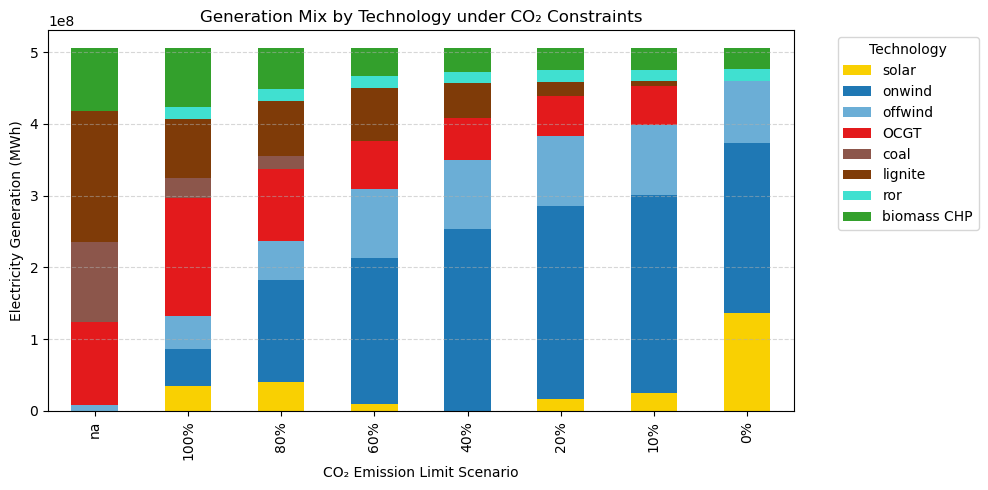

In [10]:
df_mix.columns = df_mix.columns.str.strip()

# Define new labels for emission scenarios
percent_labels = ["na", "100%", "80%", "60%", "40%", "20%", "10%", "0%"]

# Apply to both dataframes
df_mix.index = percent_labels
df_costs.index = percent_labels


# Step 2: Use updated color_map that matches your column names
color_map = {
    "solar": "#f9d002",          
    "onwind": "#1f78b4",         
    "offwind": "#6baed6",        
    "OCGT": "#e31a1c",           
    "CCGT": "#fb9a99",           
    "coal": "#8c564b",           
    "lignite": "#7f3b08",        
    "hydro": "#3182bd",          
    "ror": "#40E0D0",            
    "biomass CHP": "#33a02c",    
    "waste CHP": "#ff7f00",      
    "central gas CHP": "#a6cee3",
    "battery storage": "#6a3d9a",
    "battery inverter": "#b2df8a"
}

# Step 3: Filter df_mix columns to match color map order
df_mix = df_mix[[col for col in color_map.keys() if col in df_mix.columns]]

# Step 4: Build color list safely
colors = [color_map.get(tech, "#999999") for tech in df_mix.columns]

# Step 5: Plot
fig, ax = plt.subplots(figsize=(10, 5))
df_mix.plot(kind="bar", stacked=True, color=colors, ax=ax)

ax.set_title("Generation Mix by Technology under CO₂ Constraints")
ax.set_ylabel("Electricity Generation (MWh)")
ax.set_xlabel("CO₂ Emission Limit Scenario")
ax.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


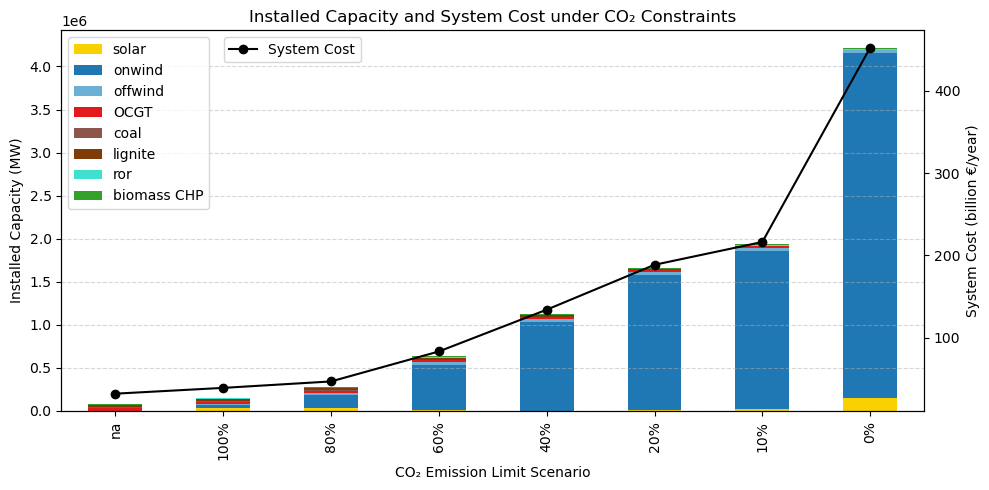

In [11]:
df_capacity = {}

for label, net in zip(percent_labels, networks):
    cap = net.generators.groupby("carrier")["p_nom_opt"].sum()
    df_capacity[label] = cap

df_capacity = pd.DataFrame(df_capacity).T.fillna(0)  # shape: (scenarios, carriers)
df_capacity.index.name = "CO₂ Scenario"

# Clean and order columns as in df_mix
df_capacity.columns = df_capacity.columns.str.strip()
df_capacity = df_capacity[[col for col in color_map.keys() if col in df_capacity.columns]]
colors_capacity = [color_map.get(tech, "#999999") for tech in df_capacity.columns]

# Ensure your index labels are aligned across both dataframes
df_capacity.index = percent_labels
df_costs.index = percent_labels

# Build consistent color list for stacked bars
df_capacity = df_capacity[[col for col in color_map.keys() if col in df_capacity.columns]]
colors_capacity = [color_map.get(tech, "#999999") for tech in df_capacity.columns]

# Create base plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot stacked bars for installed capacity
df_capacity.plot(kind="bar", stacked=True, color=colors_capacity, ax=ax1)

# Axis labels and styling for left y-axis
ax1.set_ylabel("Installed Capacity (MW)")
ax1.set_xlabel("CO₂ Emission Limit Scenario")
ax1.set_title("Installed Capacity and System Cost under CO₂ Constraints")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")

# Create second y-axis for system cost
ax2 = ax1.twinx()

# Plot system cost line
ax2.plot(df_costs.index, df_costs["System Cost [billion €]"], color="black", marker="o", label="System Cost")

# Axis label and optional grid
ax2.set_ylabel("System Cost (billion €/year)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

# Add legend for system cost
ax2.legend(bbox_to_anchor=(0.355, 1))
ax1.legend(loc="upper left")

plt.tight_layout()
plt.show()


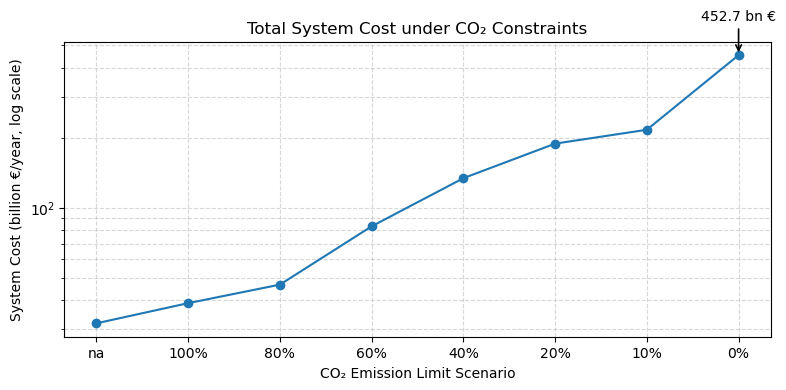

In [12]:
import matplotlib.pyplot as plt

# Log plot
fig, ax = plt.subplots(figsize=(8, 4))
df_costs["System Cost [billion €]"].plot(marker="o", ax=ax)

# Set log scale
ax.set_yscale("log")

# Annotate the last value (0% scenario)
x_pos = df_costs.index.get_loc("0%")  # get numeric x-position of "0%" label
y_val = df_costs.loc["0%", "System Cost [billion €]"]

ax.annotate(f"{y_val:.1f} bn €",
            xy=(x_pos, y_val),
            xytext=(0, 25),
            textcoords="offset points",
            ha="center",
            arrowprops=dict(arrowstyle="->", lw=1.2))

# Axes labels and styling
ax.set_title("Total System Cost under CO₂ Constraints")
ax.set_ylabel("System Cost (billion €/year, log scale)")
ax.set_xlabel("CO₂ Emission Limit Scenario")
ax.set_xticks(range(len(df_costs.index)))
ax.set_xticklabels(df_costs.index)

ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### without OCGT limit!

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_56878/283720423.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 1].legend().remove()
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_56878/283720423.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1, 1].legend().remove()


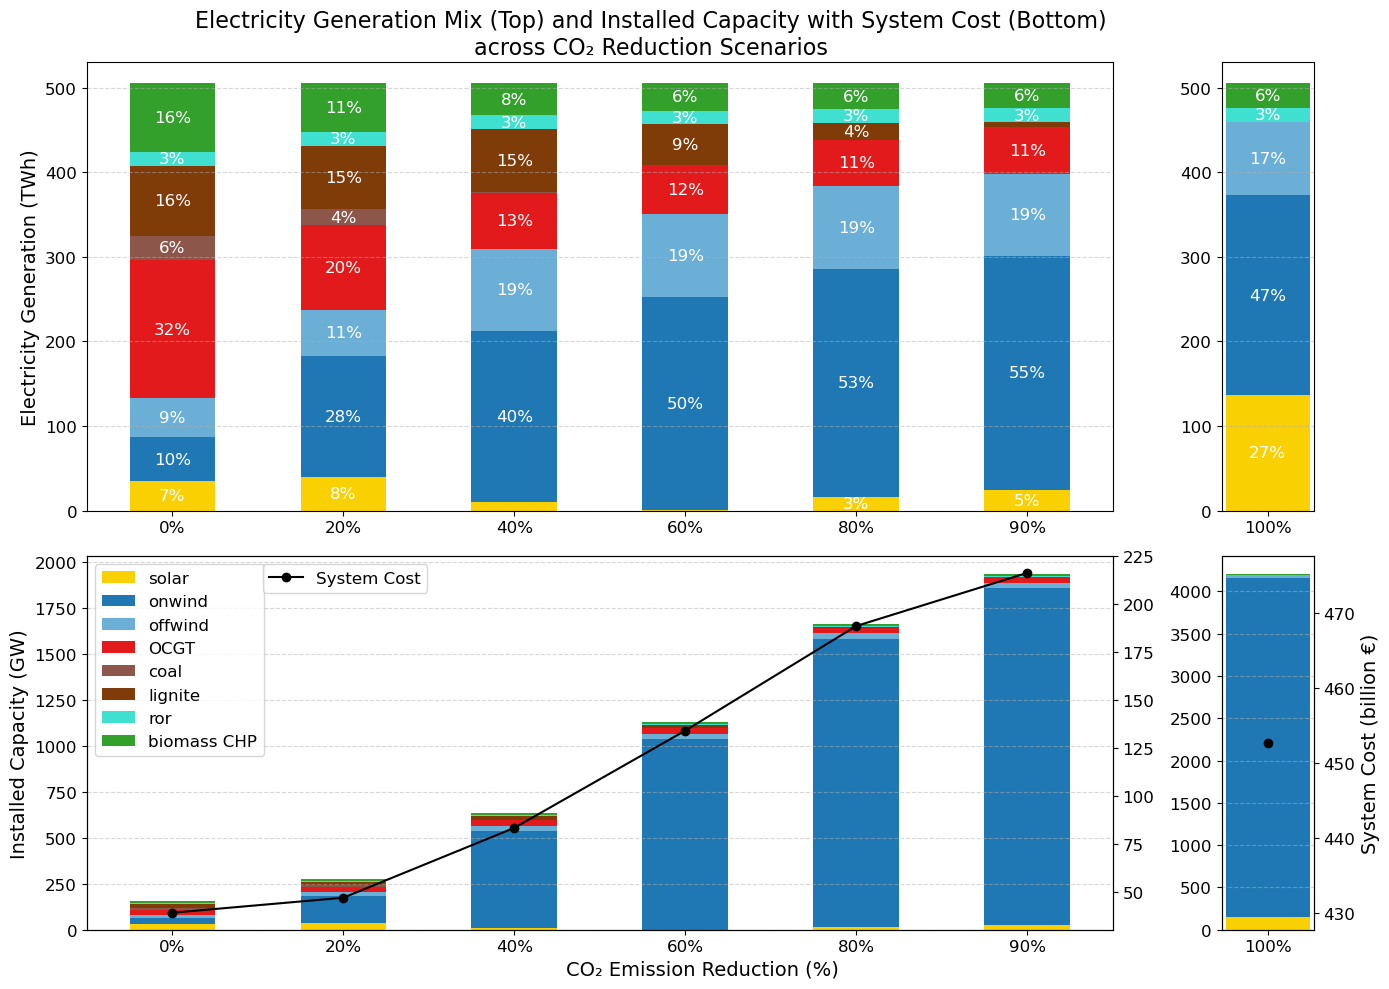

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Map allowance to reduction labels
reduction_labels_excl_0 = [f"{100 - int(l.strip('%'))}%" for l in labels_excl_0]
reduction_labels_0 = ["100%"]  # 0% allowance = 100% reduction

fig, axs = plt.subplots(2, 2, figsize=(14, 10), 
                        gridspec_kw={'width_ratios': [1, 0.09], 'height_ratios': [1.2, 1]})
plt.subplots_adjust(wspace=0.15, hspace=0.3)

# === Plot 1:1 - Generation Mix (excluding 0%) ===
bars = df_mix_excl_0 / 1e6
bars.plot(kind="bar", stacked=True, color=colors_mix, ax=axs[0, 0])
axs[0, 0].set_title("Electricity Generation Mix (Top) and Installed Capacity with System Cost (Bottom)\nacross CO₂ Reduction Scenarios", 
                    x=0.55, fontsize=16)
axs[0, 0].set_ylabel("Electricity Generation (TWh)", fontsize=14)
axs[0, 0].set_xticklabels(reduction_labels_excl_0, rotation=0, fontsize=12)
axs[0, 0].tick_params(axis='y', labelsize=12)
axs[0, 0].grid(axis="y", linestyle="--", alpha=0.5)
axs[0, 0].legend().remove()

for i, label in enumerate(labels_excl_0):
    total = bars.loc[label].sum()
    bottom = 0
    for tech, color in zip(bars.columns, colors_mix):
        val = bars.loc[label, tech]
        if val > 0:
            percent = val / total * 100
            if percent > 3:
                axs[0, 0].text(i, bottom + val / 2, f"{percent:.0f}%", 
                               ha="center", va="center", fontsize=12, color="white")
            bottom += val

# === Plot 1:2 - Generation Mix (0%) ===
bars_0 = df_mix_0 / 1e6
bottom = 0
total_0 = bars_0.loc["0%"].sum()
for tech, color in zip(bars_0.columns, colors_mix):
    val = bars_0.loc["0%", tech]
    axs[0, 1].bar("100%", val, bottom=bottom, color=color, width=0.1)
    if val > 0:
        percent = val / total_0 * 100
        if percent > 3:
            axs[0, 1].text(0, bottom + val / 2, f"{percent:.0f}%", 
                           ha="center", va="center", fontsize=12, color="white")
    bottom += val
axs[0, 1].set_title("")
axs[0, 1].set_ylabel("")
axs[0, 1].set_xticks([0])
axs[0, 1].set_xticklabels(reduction_labels_0, fontsize=12)
axs[0, 1].tick_params(axis='y', labelsize=12)
axs[0, 1].grid(axis="y", linestyle="--", alpha=0.5)
axs[0, 1].legend().remove()

# === Plot 2:1 - Installed Capacity + System Cost (excluding 0%) ===
(df_capacity_excl_0 / 1e3).plot(kind="bar", stacked=True, color=colors_capacity, ax=axs[1, 0])
axs[1, 0].set_ylabel("Installed Capacity (GW)", fontsize=14)
axs[1, 0].set_xlabel("CO₂ Emission Reduction (%)", fontsize=14, x=0.6)
axs[1, 0].set_xticklabels(reduction_labels_excl_0, rotation=0, fontsize=12)
axs[1, 0].tick_params(axis='y', labelsize=12)
axs[1, 0].grid(axis="y", linestyle="--", alpha=0.5)
axs[1, 0].legend(loc="upper left", fontsize=12)

ax2_right = axs[1, 0].twinx()
ax2_right.plot(reduction_labels_excl_0, df_costs_excl_0["System Cost [billion €]"], color="black", marker="o", label="System Cost")
ax2_right.set_ylabel("", fontsize=14)
ax2_right.tick_params(axis="y", labelcolor="black", labelsize=12)
ax2_right.legend(bbox_to_anchor=(0.34, 1), fontsize=12)

# === Plot 2:2 - Installed Capacity + Cost (0%) ===
bottom = np.zeros(1)
for tech, color in zip(df_capacity_0.columns, colors_capacity):
    axs[1, 1].bar("100%", (df_capacity_0[tech].values / 1e3), bottom=bottom, color=color, width=0.1)
    bottom += df_capacity_0[tech].values / 1e3

axs[1, 1].set_ylabel("")
axs[1, 1].set_xticks([0])
axs[1, 1].set_xticklabels(reduction_labels_0, fontsize=12)
axs[1, 1].tick_params(axis='y', labelsize=12)
axs[1, 1].grid(axis="y", linestyle="--", alpha=0.5)
axs[1, 1].legend().remove()

ax2_right_0 = axs[1, 1].twinx()
ax2_right_0.plot(reduction_labels_0, df_costs_0["System Cost [billion €]"], color="black", marker="o", label="System Cost")
ax2_right_0.set_ylabel("System Cost (billion €)", color="black", fontsize=14)
ax2_right_0.tick_params(axis="y", labelcolor="black", labelsize=12)
ax2_right_0.legend().remove()

plt.tight_layout()
plt.show()
